# Load modules

In [313]:
from glob import glob
from datetime import datetime 
import xarray as xr 
import numpy as np 
import seawater as sw
from scipy.signal import argrelextrema
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from scipy.interpolate import PchipInterpolator
from shapely.geometry import LineString
import seaborn as sns

#For plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as colors
import cmocean 

import functions

# Define directories

In [268]:
main_path = '/Users/solangecoadou/Desktop/Desktop/Thesis/Data_QUICCHE/'
path_save = '/Users/solangecoadou/Desktop/Desktop/Thesis/Figure_QUICCHE/submission/'
data_dir_SSH = main_path + 'DUACS_new/'
swot_dir = main_path + 'SWOT_last_version/'

# Define period of interest

In [269]:
start = datetime(2023, 3, 10)
stop = datetime(2023, 7, 10)

# Load data

In [270]:
### DUACS
filenames = [x for x in glob(data_dir_SSH+'*.nc')] 
filenames.sort()
ds_ssh = xr.open_mfdataset(filenames).sel(time=slice(np.datetime64(start), np.datetime64(stop)))

### SWOT
swot_files = [x for x in glob(swot_dir+'*'+'_016_'+'*.nc')] #Select only one SWOT Pass of the crossover
swot_files.sort()

# Check front detection algorithm - without orientation correction

Date: 2023-06-01


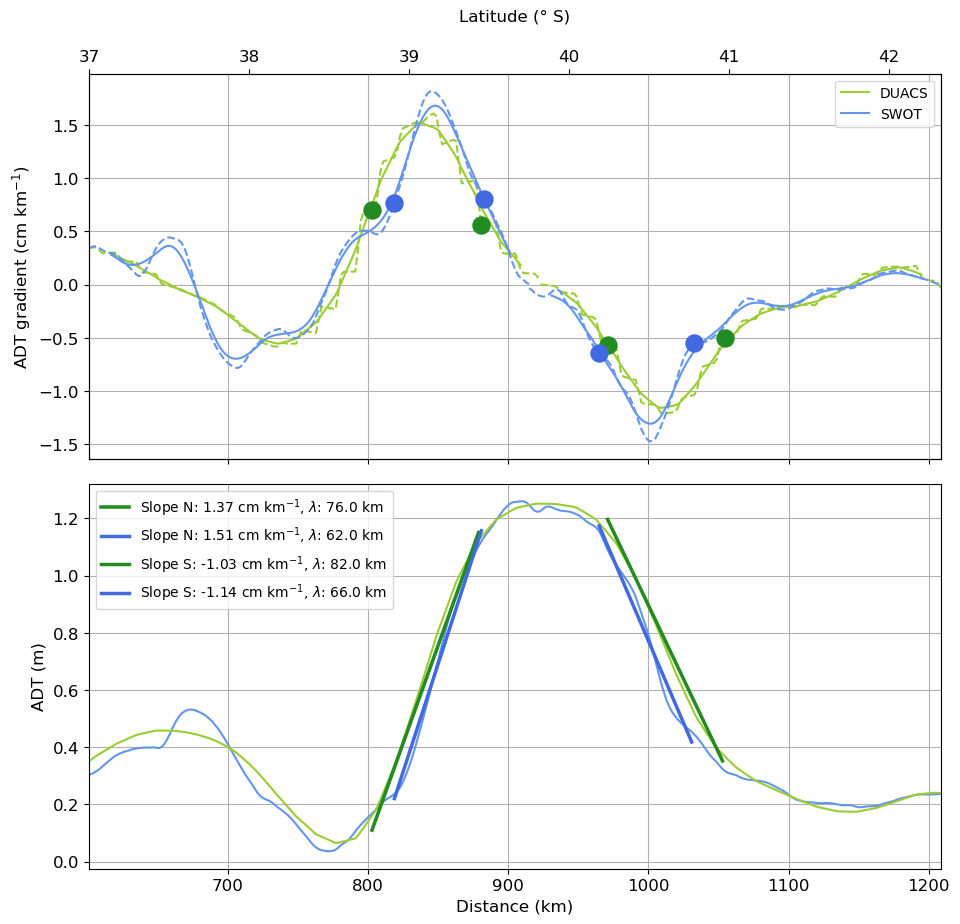

In [249]:
#Set parameters and fields for the plot:
pos_west, pos_east, pos_south, pos_north  = 10,25,-43.25,-32  #Set the area

#Check for one day and along one track
id_track = 22
id_date=58

    #Open SWOT file
swot_data = xr.open_dataset(swot_files[id_date])
date_str = swot_files[id_date][-41:-37] + '-' + swot_files[id_date][-37:-35] + '-' + swot_files[id_date][-35:-33] 
print('Date: ' + date_str)
id_select = np.unique(np.where((swot_data.longitude>pos_west) & (swot_data.longitude<pos_east) & (swot_data.latitude>pos_south) & (swot_data.latitude<pos_north))[0])
field_swot = swot_data.ssha_filtered.data[id_select][:,id_track] + swot_data.mdt.data[id_select][:,id_track]

    #Open DUACS file
date64 = np.datetime64(datetime(int(swot_files[id_date][-41:-37]), int(swot_files[id_date][-37:-35]), int(swot_files[id_date][-35:-33])))
ds_sat = ds_ssh.sel(time=date64)   

ft = 12
window=15 # For moving average
thres=0.5 # for the gradient decrease
id_nan = np.where(~np.isnan(field_swot)==1)[0]
dist_front = 100

if len(id_nan)>0: #Check if there is data
    
    # idmax is the highest ADT point in the SWOT along track data 
    idmax = np.argmax(field_swot[id_nan])
    
    # Dist_all is the along-track distance array 
    if id_nan[0]==0:
        dist_all = np.hstack([0,np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][id_nan],swot_data.longitude.data[id_select][:,id_track][id_nan],units='km')[0])])
    else: 
        dist_all = np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],swot_data.longitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],units='km')[0])
    
    # Find two indexes to cut the data to capture the Retroflection
    # After inspection of the full fast sampling phase, we found that
    # the Retroflection is always located between 600 km and 1200 km
    
    if len(np.where(dist_all>1200)[0])>0:
        id_up = np.where(dist_all>1200)[0][0]
    else:
        id_up = -1
    if len(np.where(dist_all>600)[0])>0:
        id_cut = np.where(dist_all>600)[0][0]
    else:
        id_cut=0

    # 1) if the section is shorter than 850 km, we don't capture the southern front
    # 2) if the section start above 700 km, we don't capture the northern front
    # 3) we consider that, if around the peak of the ADT (+/- 100 km), there's a gap
    # of data of more than 7 km, we discard this section as the gradient of the front
    # could be affected because poorly resolved
    # 4) if the ADT field maximum is below 0.6, then we consider that we are not crossing the 
    # Retroflection
    
    if ((dist_all[-1]>850) and (dist_all[id_cut]<700) and (len(np.where(np.diff(dist_all[idmax-50:idmax+50])>7)[0])==0)  and (np.nanmax(field_swot[id_nan][id_cut:id_up])>0.6)):
        lon_swot, lat_swot = swot_data.longitude.data[id_select][:,id_track][id_nan], swot_data.latitude.data[id_select][:,id_track][id_nan]
        if id_nan[0]==0:
            dist_swot = np.hstack([0,np.cumsum(sw.dist(lat_swot,lon_swot,units='km')[0])])
        else:
            dist_swot = np.cumsum(sw.dist(np.concatenate(([swot_data.latitude.data[id_select][0,id_track]], lat_swot)),np.concatenate(([swot_data.longitude.data[id_select][0,id_track]], lon_swot)),units='km')[0])
        
        field_swot = field_swot[~np.isnan(field_swot)]
        
        #Start figure
        fig=plt.figure(figsize=(11,5))
        ax0 = fig.add_subplot(1, 1, 1)
        pos1 = ax0.get_position()
        ax4 = fig.add_axes([pos1.x0, pos1.y0-pos1.height-0.05, pos1.width, pos1.height])
        
           #Interpolate DUACS on SWOT tracks
        x = xr.DataArray(lon_swot,dims="new_coord")
        y = xr.DataArray(lat_swot,dims="new_coord")
        field_gridded = (ds_sat.adt).interp(longitude=x, latitude=y).compute().data
        
            #Plot SWOT & DUACS - raw data
        ax4.plot(dist_swot, field_swot, 'cornflowerblue', linewidth=1.5)
        ax4.plot(dist_swot, field_gridded, 'yellowgreen', linewidth=1.5)

            #SWOT - smooth data
        dist_swot = moving_average(dist_swot, window)
        field_swot = moving_average(field_swot, window)
        field_gridded = field_gridded[window//2:-window//2] #to have the same size as dist_swot and field_swot

        # Find two indexes to cut the data to capture the Retroflection
        # After inspection of the full fast sampling phase, we found that
        # the Retroflection is always located between 600 km and 1200 km  
        
        id_cut = np.where(dist_swot>600)[0][0]
        if len(np.where(dist_swot>1200)[0])>0:
            id_up = np.where(dist_swot>1200)[0][0]
        else:
            id_up = -1
            
        #Reduce fields to the selected portion
        field_swot = field_swot[id_cut:id_up]
        field_gridded = field_gridded[id_cut:id_up]
        dist_swot = dist_swot[id_cut:id_up]
        lat_swot = lat_swot[id_cut:id_up]
        
        
        
        
        #Plot detection North - Gridded
        dist = dist_swot[:np.argmax(field_gridded)+1]
        field = field_gridded[:np.argmax(field_gridded)+1]

        lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'north')
        ll = np.round(absc[-1] - absc[0])
        ax4.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'forestgreen', linewidth=2.55, label= 'Slope N: ' + str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$, $\lambda$: ' + str(ll) + ' km')

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)
        
        id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
        id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]
        
        # look for the indexes (in both direction) from where the gradient has decreased by half (thres)
        # from its maximum value 
        
        lim_grad = thres*grad_smooth[id_max_extrema]
        if len(np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0])>0:
            id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0][0]+window//2
        else:
            id1 = window//2
        if len(np.where(grad_smooth[id_max_extrema:]<lim_grad)[0])>0:
            id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]<lim_grad)[0][0]+window//2+1
        else:
            id2=-window//2
                
        ax0.plot(dist, grad*100, 'yellowgreen', linestyle='--', linewidth=1.5)
        ax0.plot(moving_average(dist, window), grad_smooth*100, 'yellowgreen', linewidth=1.5)
        ax0.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 150, 'forestgreen', zorder=3)

        
        
        #Plot detection North - SWOT

        dist = dist_swot[:np.argmax(field_swot)+1]
        field = field_swot[:np.argmax(field_swot)+1]

        lin_reg, absc = compute_grad_SWOT(dist, field, 'north', loc_front)
        ll = np.round(absc[-1] - absc[0])
        ax4.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'royalblue', linewidth=2.5, label= 'Slope N: ' + str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$, $\lambda$: ' + str(ll) + ' km')

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)

        id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
        id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]

        if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
            id_extre_sort = np.array(argrelextrema(grad_smooth, np.greater))[0][np.flip(np.argsort(grad_smooth[argrelextrema(grad_smooth, np.greater)]))[1:]]
            pot = id_extre_sort[0]
            while abs(moving_average(dist, window)[pot]-loc_front)>dist_front:
                id_extre_sort = id_extre_sort[1:]
                pot = id_extre_sort[0]
            id_max_extrema = pot

        lim_grad = thres*grad_smooth[id_max_extrema]
        if len(np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0])>0:
            id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0][0]+window//2
        else:
            id1 = window//2
        if len(np.where(grad_smooth[id_max_extrema:]<lim_grad)[0])>0:
            id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]<lim_grad)[0][0]+window//2+1
        else:
            id2=-window//2
        
        ax0.plot(dist, grad*100, 'cornflowerblue', linestyle='--', linewidth=1.5)
        ax0.plot(moving_average(dist, window), grad_smooth*100, 'cornflowerblue', linewidth=1.5)
        ax0.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 150, 'royalblue', zorder=3)
        
        
        
        #Plot detection South - Gridded
        
        dist = dist_swot[np.argmax(field_gridded):]
        field = field_gridded[np.argmax(field_gridded):]

        lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'south')
        ll = np.round(absc[-1] - absc[0])
        ax4.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'forestgreen', linewidth=2.5,label= 'Slope S: ' + str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$, $\lambda$: ' + str(ll) + ' km')

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)

        id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
        id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]
        lim_grad = thres*grad_smooth[id_max_extrema]
        
        if len(np.where(grad_smooth[id_max_extrema:]>lim_grad)[0])>0:
            id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]>lim_grad)[0][0]+window//2+1
        else:
            id2 = -window//2

        if len(np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0])>0:
            id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0][0]+window//2
        else:
            id1=window//2

        ax0.plot(moving_average(dist, window), grad_smooth*100, 'yellowgreen', linewidth=1.5, label='DUACS')
        ax0.plot(dist, grad*100, 'yellowgreen',linestyle='--', linewidth=1.5)
        ax0.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 150, 'forestgreen', zorder=3)

        

        
        #Plot detection South - SWOT

        dist = dist_swot[np.argmax(field_swot):]
        field = field_swot[np.argmax(field_swot):]

        if (len(field)>10) and (len(np.where((dist-loc_front)<dist_front)[0]))>0:

            lin_reg, absc = compute_grad_SWOT(dist, field, 'south', loc_front)
            ll = np.round(absc[-1] - absc[0])
            ax4.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'royalblue', linewidth=2.5, label= 'Slope S: ' + str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$, $\lambda$: ' + str(ll) + ' km')

            grad = np.gradient(field,dist)
            grad_smooth = moving_average(grad, window)

            id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
            id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]
            if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
                id_extre_sort = np.array(argrelextrema(grad_smooth, np.less))[0][np.argsort(grad_smooth[argrelextrema(grad_smooth, np.less)])[1:]]
                pot = id_extre_sort[0]
                while abs(moving_average(dist, window)[pot]-loc_front)>dist_front:
                    id_extre_sort = id_extre_sort[1:]
                    pot = id_extre_sort[0]
                id_max_extrema = pot

            lim_grad = thres*grad_smooth[id_max_extrema]

            if len(np.where(grad_smooth[id_max_extrema:]>lim_grad)[0])>0:
                id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]>lim_grad)[0][0]+window//2+1
            else:
                id2 = -window//2

            if len(np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0])>0:
                id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0][0]+window//2
            else:
                id1=window//2

            ax0.plot(moving_average(dist, window), grad_smooth*100, 'cornflowerblue', linewidth=1.5, label='SWOT')
            ax0.plot(dist, grad*100, 'cornflowerblue', linestyle='--', linewidth=1.5)
            ax0.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 150, 'royalblue', zorder=3)

            
            
        #Set parameters plot
        
        ax4.grid()
        ax4.tick_params('both', labelsize=ft)
        ax4.set_xlabel('Distance (km)', fontsize=ft)
        ax4.set_ylabel('ADT (m)', fontsize=ft)
        ax4.set_xlim([np.min(dist_swot),np.max(dist_swot)])
        plt.legend(fontsize=ft-2)
            
        ax0.grid()
        ax0.tick_params('both', labelsize=ft)
        ax0.set_xlim([np.min(dist_swot),np.max(dist_swot)])
        ax0.set_ylabel('ADT gradient (cm km$^{-1}$)', fontsize=ft)
        ax0.set_xticklabels([])
        ax0.legend(fontsize=ft-2)

        #Add latitude as second x-axis
        ax0ghost=ax0.twiny()
        ax0ghost.plot(-lat_swot, field_swot, alpha=0)
        ax0ghost.set_xlim(-lat_swot[0], -lat_swot[-1])
        ax0ghost.tick_params(labelsize=ft)
        plt.xlabel('Latitude (° S)', fontsize=ft, labelpad=20)
        
        #fig.savefig(path_save + 'Gradient_check/' + swot_files[id_date][-41:-33] + '_' + str(id_track) + '.png', bbox_inches='tight', dpi=300)


# Check angle computation algorithm

Date: 2023-06-01


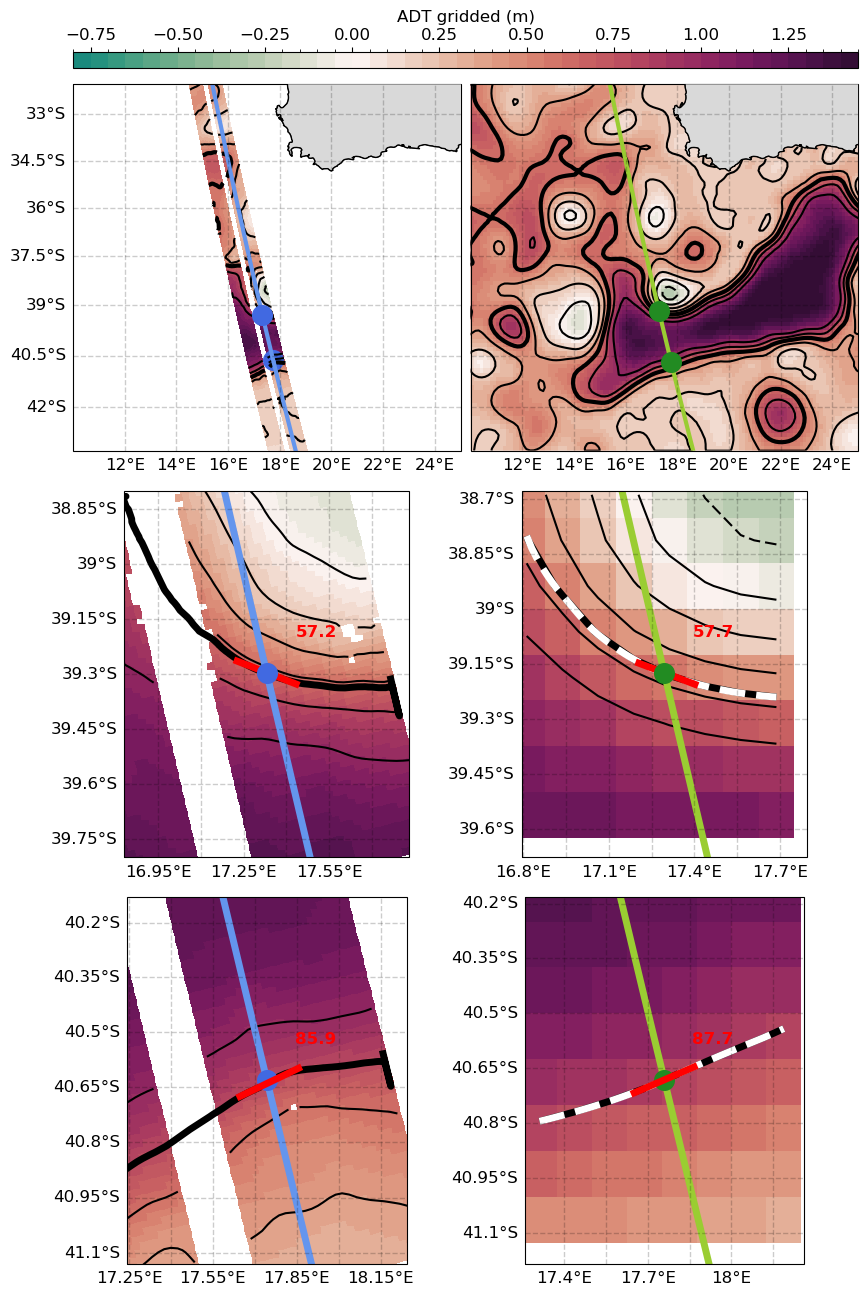

In [195]:
#Set parameters and fields for the plot:
pos_west, pos_east, pos_south, pos_north  = 10,25,-43.25,-32  #Set the area

#Check for one day and along one track
id_track = 22
id_date=58

    #Open SWOT file
swot_data = xr.open_dataset(swot_files[id_date])
date_str = swot_files[id_date][-41:-37] + '-' + swot_files[id_date][-37:-35] + '-' + swot_files[id_date][-35:-33] 
print('Date: ' + date_str)
id_select = np.unique(np.where((swot_data.longitude>pos_west) & (swot_data.longitude<pos_east) & (swot_data.latitude>pos_south) & (swot_data.latitude<pos_north))[0])
field_swot = swot_data.ssha_filtered.data[id_select][:,id_track] + swot_data.mdt.data[id_select][:,id_track]

    #Open DUACS file
date64 = np.datetime64(datetime(int(swot_files[id_date][-41:-37]), int(swot_files[id_date][-37:-35]), int(swot_files[id_date][-35:-33])))
ds_sat = ds_ssh.sel(time=date64)   

ft = 12
window=15 # For moving average
thres=0.5 # for the gradient decrease
retro_thresh = 0.6
id_nan = np.where(~np.isnan(field_swot)==1)[0]
dist_front = 100
delta = 0.5 #Distance in degree around the front location (for plotting purpose only)
radius = 10 #in km

    #Set projection
proj = ccrs.Mercator(central_longitude=16, min_latitude=pos_south, max_latitude=pos_north)
crs = ccrs.PlateCarree()
extent = [pos_west, pos_east, pos_south, pos_north]
cartmap = proj, crs, extent

    #Set the colorbar properties
Tinc=np.arange(-0.8,1.5, 0.05)
cmap = cmocean.tools.crop(cmocean.cm.curl, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
label_colorbar = 'ADT gridded (m)'
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

if len(id_nan)>0: #Check if there is data
    
    # idmax is the highest ADT point in the SWOT along track data 
    idmax = np.argmax(field_swot[id_nan])
    
    # Dist_all is the along-track distance array 
    if id_nan[0]==0:
        dist_all = np.hstack([0,np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][id_nan],swot_data.longitude.data[id_select][:,id_track][id_nan],units='km')[0])])
    else: 
        dist_all = np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],swot_data.longitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],units='km')[0])
    
    # Find two indexes to cut the data to capture the Retroflection
    # After inspection of the full fast sampling phase, we found that
    # the Retroflection is always located between 600 km and 1200 km
    
    if len(np.where(dist_all>1200)[0])>0:
        id_up = np.where(dist_all>1200)[0][0]
    else:
        id_up = -1
    if len(np.where(dist_all>600)[0])>0:
        id_cut = np.where(dist_all>600)[0][0]
    else:
        id_cut=0

    # 1) if the section is shorter than 850 km, we don't capture the southern front
    # 2) if the section start above 700 km, we don't capture the northern front
    # 3) we consider that, if around the peak of the ADT (+/- 100 km), there's a gap
    # of data of more than 7 km, we discard this section as the gradient of the front
    # could be affected because poorly resolved
    # 4) if the ADT field maximum is below 0.6, then we consider that we are not crossing the 
    # Retroflection
    
    if ((dist_all[-1]>850) and (dist_all[id_cut]<700) and (len(np.where(np.diff(dist_all[idmax-50:idmax+50])>7)[0])==0)  and (np.nanmax(field_swot[id_nan][id_cut:id_up])>0.6)):
        lon_swot, lat_swot = swot_data.longitude.data[id_select][:,id_track][id_nan], swot_data.latitude.data[id_select][:,id_track][id_nan]
        if id_nan[0]==0:
            dist_swot = np.hstack([0,np.cumsum(sw.dist(lat_swot,lon_swot,units='km')[0])])
        else:
            dist_swot = np.cumsum(sw.dist(np.concatenate(([swot_data.latitude.data[id_select][0,id_track]], lat_swot)),np.concatenate(([swot_data.longitude.data[id_select][0,id_track]], lon_swot)),units='km')[0])
        
        field_swot = field_swot[~np.isnan(field_swot)]
        
        #Define direction vector of SWOT track
        track_vect = np.array([lon_swot[0] - lon_swot[-1], lat_swot[0] - lat_swot[-1]])
        track_vect_unit = track_vect/np.linalg.norm(track_vect)
        
        #Start figure
        fig=plt.figure(figsize=(5,8))

        #Plot SWOT data
        ax0 = fig.add_subplot(1, 1, 1,projection=proj, zorder=8)
        ax0.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
        ax0.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
        ax0.set_extent(extent)
        map_grid=ax0.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
        map_grid.top_labels = False
        map_grid.left_labels = True
        map_grid.right_labels = False
        map_grid.xlabel_style = {'size': ft}
        map_grid.ylabel_style = {'size': ft}
        
        #Plot SWOT ADT
        im = ax0.pcolormesh(swot_data.longitude.data[id_select], swot_data.latitude.data[id_select], swot_data.ssha_filtered.data[id_select] + swot_data.mdt.data[id_select], cmap=cmap, norm=norm,transform=crs)
        ax0.contour(swot_data.longitude.data[id_select], swot_data.latitude.data[id_select], swot_data.ssha_filtered.data[id_select] + swot_data.mdt.data[id_select], levels=np.arange(-1,1.2,0.2), colors='k', linewidths=1.5,transform=crs)
        ax0.contour(swot_data.longitude.data[id_select], swot_data.latitude.data[id_select], swot_data.ssha_filtered.data[id_select] + swot_data.mdt.data[id_select], levels=[retro_thresh], colors='k', linewidths=3,transform=crs)

        #Add track of interest
        ax0.plot(lon_swot, lat_swot, 'cornflowerblue', linewidth=3, transform=crs)
        plt.grid()
        plt.gca().tick_params('both', labelsize=ft)
            
        #Plot DUACS ADT 
        pos1 = ax0.get_position()
        ax1 = fig.add_axes([pos1.x0 + pos1.width + 0.02, pos1.y0, pos1.width, pos1.height],projection=proj)
        map_fig_one(fig, ax1, ds_sat)
        ax1.plot(lon_swot, lat_swot, 'yellowgreen', linewidth=3, transform=crs)
        
        #Add colorbar
        cax = fig.add_axes([pos1.x0, pos1.y0+pos1.height+0.02, 2*pos1.width + 0.02, 0.02])
        cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
        cbar.set_label(label_colorbar, fontsize=ft)
        cax.xaxis.set_label_position('top')
        cax.xaxis.set_ticks_position('top')
        cbar.ax.tick_params(labelsize=ft)
        
        
           #Interpolate DUACS on SWOT tracks
        x = xr.DataArray(lon_swot,dims="new_coord")
        y = xr.DataArray(lat_swot,dims="new_coord")
        field_gridded = (ds_sat.adt).interp(longitude=x, latitude=y).compute().data

            #SWOT - smooth data
        dist_swot = moving_average(dist_swot, window)
        field_swot = moving_average(field_swot, window)
        field_gridded = field_gridded[window//2:-window//2] #to have the same size as dist_swot and field_swot

        # Find two indexes to cut the data to capture the Retroflection
        # After inspection of the full fast sampling phase, we found that
        # the Retroflection is always located between 600 km and 1200 km  
        
        id_cut = np.where(dist_swot>600)[0][0]
        if len(np.where(dist_swot>1200)[0])>0:
            id_up = np.where(dist_swot>1200)[0][0]
        else:
            id_up = -1
            
        #Reduce fields to the selected portion
        field_swot = field_swot[id_cut:id_up]
        field_gridded = field_gridded[id_cut:id_up]
        dist_swot = dist_swot[id_cut:id_up]
        
        #Plot detection North - Gridded
        dist = dist_swot[:np.argmax(field_gridded)+1]
        field = field_gridded[:np.argmax(field_gridded)+1]

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)
        
        id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
        id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]
        
        #Plot front location
        lon_c, lat_c = lon_swot[window//2:-window//2][id_cut:id_up][:np.argmax(field_gridded)+1][id_max_extrema+window//2], lat_swot[window//2:-window//2][id_cut:id_up][:np.argmax(field_gridded)+1][id_max_extrema+window//2]
        adt_c = field[id_max_extrema+window//2]
        ax1.scatter(lon_c, lat_c, 200, 'forestgreen', transform=crs, zorder=20)
        
        #Reduce DUACS around the front location and plot the resulting map
        ds_sel = ds_sat.sel(longitude=slice(lon_c-delta,lon_c+delta), latitude=slice(lat_c-delta,lat_c+delta))
        
        ax4 = fig.add_axes([pos1.x0 + pos1.width + 0.02, pos1.y0-pos1.height-0.05, pos1.width, pos1.height],projection=proj)
        ax4.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
        ax4.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
        ax4.set_extent([lon_c-delta, lon_c+delta, lat_c-delta, lat_c+delta])
        map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
        map_grid.top_labels = False
        map_grid.left_labels = True
        map_grid.right_labels = False
        map_grid.xlabel_style = {'size': ft}
        map_grid.ylabel_style = {'size': ft}

        im = ax4.pcolormesh(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, cmap=cmap, norm=norm, transform=crs)
        ax4.contour(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, levels=np.arange(-1,1,0.2), colors='k', linewidths=1.5,transform=crs)

        #Add the contour level of the point defining the front location
        cs = ax4.contour(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, levels=[adt_c], colors='k', linewidths=5,transform=crs)    
        
        ax4.scatter(lon_c, lat_c, 200, 'forestgreen', transform=crs, zorder=20)
        ax4.plot(lon_swot, lat_swot, 'yellowgreen', linewidth=5, transform=crs)
        
        loc_front = moving_average(dist, window)[id_max_extrema]
        
        #Make regression along contour level cs to have more points to compute the tangent
        # to that contour at the location of the front
        
            #Contains the length of each contour
        length_contour = [len(cs.allsegs[0][j][:,0]) for j in range(len(cs.allsegs[0]))]
        
            #We condider only the longuest contour as the one representing the retroflection
            # Might have to change in different configuration
        id_cont = np.argsort(length_contour)[-1]
        
            #Interpolation will be conducted over the latitudes. As the interpolation we use
            # only works on monotonous curves, we will apply it to successive monotonous 
            # sections of the contours
        
        if monotonic(cs.allsegs[0][id_cont][:,0]):
            id_split = np.array([0,len(cs.allsegs[0][id_cont][:,0])-1])
        else:
            delta_sign = np.sign(np.diff(cs.allsegs[0][id_cont][:-1,0]))-np.sign(np.diff(cs.allsegs[0][id_cont][1:,0]))
            id_change_sign = np.where(delta_sign!=0)[0]
            id_split = np.concatenate(([0],id_change_sign+1,[len(cs.allsegs[0][id_cont][:,0])-1]))

        xsel=[]
        ysel=[]
        
            # PchipInterpolator only works on stricly increasing points
        for p in range(len(id_split)-1):
            nb_points = int(np.round((id_split[p+1]-id_split[p])*50/(len(cs.allsegs[0][id_cont][:,0])-1)))
            if cs.allsegs[0][id_cont][id_split[p],0]<cs.allsegs[0][id_cont][id_split[p+1],0]:
                xorg = cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,0]
                yorg = cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,1]
                xinterp = np.linspace(cs.allsegs[0][id_cont][id_split[p],0],cs.allsegs[0][id_cont][id_split[p+1],0],nb_points)
            else:
                xorg = np.flip(cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,0])
                yorg = np.flip(cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,1])
                xinterp = np.linspace(cs.allsegs[0][id_cont][id_split[p+1],0], cs.allsegs[0][id_cont][id_split[p],0],nb_points)
            spl = PchipInterpolator(xorg, yorg)
            
            ax4.plot(xinterp, spl(xinterp) , 'w--', linewidth=5, transform=crs)
            
            #Only 'remember' points that are less than radius away from the front location
            for r in range(nb_points):
                if sw.dist([lat_c, spl(xinterp)[r]],[lon_c, xinterp[r]],units='km')[0]<radius:
                    xsel.append(xinterp[r])
                    ysel.append(spl(xinterp)[r])
                    
        xsel=np.array(xsel)
        ysel=np.array(ysel)
        
            #Compute linear regression on the selected points of the interpolated contour

        lin_reg = LinearRegression()
        lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))
        y_pred = lin_reg.predict(np.array([xsel[0], xsel[-1]]).reshape(-1, 1))[:,0]
        ax4.plot([xsel[0], xsel[-1]], y_pred, 'r', linewidth=5, transform=crs, zorder=12)
        
        # Define direction vector of the tangent vector to the contour
        reg_vect = np.array([xsel[0] - xsel[-1], y_pred[0] - y_pred[-1]])
        reg_vect_unit = reg_vect/np.linalg.norm(reg_vect)

        # Compute the angle between the contour and the SWOT track (always below 90 degree)
        angle = np.rad2deg(np.arccos(np.dot(track_vect_unit,reg_vect_unit)))
        if angle >90:
            angle = 180 - angle
        ax4.text(lon_c + 0.1,lat_c + 0.1,str(np.round(angle*10)/10), fontsize=ft, fontweight='semibold', color='r',transform=crs, zorder=10)

        
        #Plot detection North - SWOT
    
        dist = dist_swot[:np.argmax(field_swot)+1]
        field = field_swot[:np.argmax(field_swot)+1]

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)
    
        id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
        id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]
            
        if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
            id_extre_sort = np.array(argrelextrema(grad_smooth, np.greater))[0][np.flip(np.argsort(grad_smooth[argrelextrema(grad_smooth, np.greater)]))[1:]]
            pot = id_extre_sort[0]
            while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
                id_extre_sort = id_extre_sort[1:]
                pot = id_extre_sort[0]
            if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
                id_max_extrema = pot
            else:
                id_max_extrema = np.argmax(grad_smooth)
                
        #Plot front location
        lon_c, lat_c = moving_average(lon_swot, window)[id_cut:id_up][:np.argmax(field_swot)+1][id_max_extrema+window//2], moving_average(lat_swot, window)[id_cut:id_up][:np.argmax(field_swot)+1][id_max_extrema+window//2]
        adt_c = field[id_max_extrema+window//2]
        ax0.scatter(lon_c, lat_c, 200, 'royalblue', transform=crs, zorder=20)
        
        #Reduce SWOT around the front location and plot the resulting map
        ax5 = fig.add_axes([pos1.x0, pos1.y0-pos1.height-0.05, pos1.width, pos1.height],projection=proj)
        ax5.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
        ax5.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
        ax5.set_extent([lon_c-delta, lon_c+delta, lat_c-delta, lat_c+delta])
        map_grid=ax5.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
        map_grid.top_labels = False
        map_grid.left_labels = True
        map_grid.right_labels = False
        map_grid.xlabel_style = {'size': ft}
        map_grid.ylabel_style = {'size': ft}
                    
        id_sel = np.unique(np.where((swot_data.longitude>lon_c-delta) & (swot_data.longitude<lon_c+delta) & (swot_data.latitude>lat_c-delta) & (swot_data.latitude<lat_c+delta))[0])

        ds_sel_adt = swot_data.ssha_filtered.data[id_sel] + swot_data.mdt.data[id_sel]
        row, col = np.where(~np.isnan(ds_sel_adt)==1)

        im = ax5.pcolormesh(swot_data.longitude.data[id_sel], swot_data.latitude.data[id_sel], ds_sel_adt, cmap=cmap, norm=norm, transform=crs)
        cs = ax5.tricontour(swot_data.longitude.data[id_sel][row,col].flatten(), swot_data.latitude.data[id_sel][row,col].flatten(), ds_sel_adt[row,col].flatten(), [adt_c], transform=crs, colors='k', linewidths=5, zorder=12)
        ax5.contour(swot_data.longitude.data[id_sel], swot_data.latitude.data[id_sel], swot_data.ssha_filtered.data[id_sel] + swot_data.mdt.data[id_sel], levels=np.arange(-1,1.2,0.2), colors='k', linewidths=1.5,transform=crs)

        ax5.scatter(lon_c, lat_c, 200, 'royalblue', transform=crs, zorder=20)
        ax5.plot(lon_swot, lat_swot, 'cornflowerblue', linewidth=5, transform=crs)
        
        #Find contour that intersect SWOT track and is the closest to the front location
        list_inters = []
        idx_ct = []
        for j in range(len(cs.allsegs[0])):
            lines = LineString(cs.allsegs[0][j]).intersection(LineString(np.vstack((lon_swot,lat_swot)).T))
            if not(lines.is_empty):
                if lines.geom_type == 'MultiPoint':
                    lines = lines.geoms[0]
                list_inters.append(sw.dist([lat_c, lines.y],[lon_c, lines.x],units='km')[0])
                idx_ct.append(j)

        contour_select = idx_ct[np.argmin(list_inters)]
        
        #Select only a few points of that contour to make the linear regression
        xsel=[]
        ysel=[]
        if id_track==7:
            rr=radius/2
        else:
            rr=radius
        for p in range(len(cs.allsegs[0][contour_select][:,0])):
            if sw.dist([lat_c, cs.allsegs[0][contour_select][p,1]],[lon_c, cs.allsegs[0][contour_select][p,0]],units='km')[0]<rr:
                xsel.append(cs.allsegs[0][contour_select][p,0])
                ysel.append(cs.allsegs[0][contour_select][p,1])
        xsel=np.array(xsel)
        ysel=np.array(ysel)
        
        lin_reg = LinearRegression()
        lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))
        y_pred = lin_reg.predict(np.array([xsel[0], xsel[-1]]).reshape(-1, 1))[:,0]
        ax5.plot([xsel[0], xsel[-1]], y_pred, 'r', linewidth=5, transform=crs, zorder=12)

        reg_vect = np.array([xsel[0] - xsel[-1], y_pred[0] - y_pred[-1]])
        reg_vect_unit = reg_vect/np.linalg.norm(reg_vect)

        angle = np.rad2deg(np.arccos(np.dot(track_vect_unit,reg_vect_unit)))
        if angle >90:
            angle = 180 - angle
        ax5.text(lon_c + 0.1,lat_c + 0.1,str(np.round(angle*10)/10), fontsize=ft, fontweight='semibold', color='r',transform=crs, zorder=15)

        
        #Plot detection South - Gridded (same as before)
        
        dist = dist_swot[np.argmax(field_gridded):]
        field = field_gridded[np.argmax(field_gridded):]

        grad = np.gradient(field,dist)
        grad_smooth = moving_average(grad, window)

        id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
        id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]
        
        lon_c, lat_c = lon_swot[window//2:-window//2][id_cut:id_up][np.argmax(field_gridded):][id_max_extrema+window//2], lat_swot[window//2:-window//2][id_cut:id_up][np.argmax(field_gridded):][id_max_extrema+window//2]
        adt_c = field[id_max_extrema+window//2]

        ax1.scatter(lon_c, lat_c, 200, 'forestgreen', transform=crs, zorder=12)

        ds_sel = ds_sat.sel(longitude=slice(lon_c-delta,lon_c+delta), latitude=slice(lat_c-delta,lat_c+delta))

        ax6 = fig.add_axes([pos1.x0 + pos1.width + 0.02, pos1.y0-2*pos1.height-2*0.05, pos1.width, pos1.height],projection=proj)
        ax6.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
        ax6.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
        ax6.set_extent([lon_c-delta, lon_c+delta, lat_c-delta, lat_c+delta])
        map_grid=ax6.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
        map_grid.top_labels = False
        map_grid.left_labels = True
        map_grid.right_labels = False
        map_grid.xlabel_style = {'size': ft}
        map_grid.ylabel_style = {'size': ft}

        im = ax6.pcolormesh(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, cmap=cmap, norm=norm, transform=crs)
        cs = ax6.contour(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, levels=[adt_c], colors='k', linewidths=5,transform=crs)    
        ax6.contour(ds_sel.longitude, ds_sel.latitude, ds_sel.adt, levels=np.arange(-1,1,0.2), colors='k', linewidths=1.5,transform=crs)
        ax6.scatter(lon_c, lat_c, 200, 'forestgreen', transform=crs, zorder=12)

        ax6.plot(lon_swot, lat_swot, 'yellowgreen', linewidth=5, transform=crs)

        loc_front = moving_average(dist, window)[id_max_extrema]
        
        #Make regression along contour level cs to have more points to compute the tangent
        # to that contour at the location of the front
        
        length_contour = [len(cs.allsegs[0][j][:,0]) for j in range(len(cs.allsegs[0]))]
       
        id_cont = np.argsort(length_contour)[-1]

        if monotonic(cs.allsegs[0][id_cont][:,0]):
            id_split = np.array([0,len(cs.allsegs[0][id_cont][:,0])-1])
        else:
            delta_sign = np.sign(np.diff(cs.allsegs[0][id_cont][:-1,0]))-np.sign(np.diff(cs.allsegs[0][id_cont][1:,0]))
            id_change_sign = np.where(delta_sign!=0)[0]
            id_split = np.concatenate(([0],id_change_sign+1,[len(cs.allsegs[0][id_cont][:,0])-1]))
            
        xsel=[]
        ysel=[]
        
        for p in range(len(id_split)-1):
            nb_points = int(np.round((id_split[p+1]-id_split[p])*50/(len(cs.allsegs[0][id_cont][:,0])-1)))
            if cs.allsegs[0][id_cont][id_split[p],0]<cs.allsegs[0][id_cont][id_split[p+1],0]:
                xorg = cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,0]
                yorg = cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,1]
                xinterp = np.linspace(cs.allsegs[0][id_cont][id_split[p],0],cs.allsegs[0][id_cont][id_split[p+1],0],nb_points)
            else:
                xorg = np.flip(cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,0])
                yorg = np.flip(cs.allsegs[0][id_cont][id_split[p]:id_split[p+1]+1,1])
                xinterp = np.linspace(cs.allsegs[0][id_cont][id_split[p+1],0], cs.allsegs[0][id_cont][id_split[p],0],nb_points)
            spl = PchipInterpolator(xorg, yorg)
            ax6.plot(xinterp, spl(xinterp) , 'w--', linewidth=5, transform=crs)
            for r in range(nb_points):
                if sw.dist([lat_c, spl(xinterp)[r]],[lon_c, xinterp[r]],units='km')[0]<radius:
                    xsel.append(xinterp[r])
                    ysel.append(spl(xinterp)[r])
                
        xsel=np.array(xsel)
        ysel=np.array(ysel)
        
        lin_reg = LinearRegression()
        lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))

        lin_reg = LinearRegression()
        lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))
        y_pred = lin_reg.predict(np.array([xsel[0], xsel[-1]]).reshape(-1, 1))[:,0]

        ax6.plot([xsel[0], xsel[-1]], y_pred, 'r', linewidth=5, transform=crs, zorder=12)

        reg_vect = np.array([xsel[0] - xsel[-1], y_pred[0] - y_pred[-1]])
        reg_vect_unit = reg_vect/np.linalg.norm(reg_vect)

        angle = np.rad2deg(np.arccos(np.dot(track_vect_unit,reg_vect_unit)))
        if angle >90:
            angle = 180 - angle
        ax6.text(lon_c + 0.1,lat_c + 0.1,str(np.round(angle*10)/10), fontsize=ft, fontweight='semibold', color='r',transform=crs, zorder=10)
        
        
         #Plot detection South - SWOT (same as above)
    
        dist = dist_swot[np.argmax(field_swot):]
        field = field_swot[np.argmax(field_swot):]

        if (len(field)>10) and (len(np.where((dist-loc_front)<dist_front)[0]))>0:

            grad = np.gradient(field,dist)
            grad_smooth = moving_average(grad, window)

            #mmax_grad = np.argmin(grad_smooth)
            id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
            id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]

            if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
                id_extre_sort = np.array(argrelextrema(grad_smooth, np.less))[0][np.argsort(grad_smooth[argrelextrema(grad_smooth, np.less)])[1:]]
                pot = id_extre_sort[0]
                while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
                    id_extre_sort = id_extre_sort[1:]
                    pot = id_extre_sort[0]
                if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
                    id_max_extrema = pot
                else:
                    id_max_extrema = np.argmin(grad_smooth)
            
            lon_c, lat_c = moving_average(lon_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2], moving_average(lat_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2]
            adt_c = field[id_max_extrema+window//2]
            
            ax0.scatter(lon_c, lat_c, 200, 'royalblue', transform=crs)

            ax7 = fig.add_axes([pos1.x0, pos1.y0-2*pos1.height-2*0.05, pos1.width, pos1.height],projection=proj)
            ax7.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))#facecolor=(0.95,0.95,0.95))#,alpha=0.1)
            ax7.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
            ax7.set_extent([lon_c-delta, lon_c+delta, lat_c-delta, lat_c+delta])
            map_grid=ax7.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
            map_grid.top_labels = False
            map_grid.left_labels = True
            map_grid.right_labels = False
            map_grid.xlabel_style = {'size': ft}
            map_grid.ylabel_style = {'size': ft}

            id_sel = np.unique(np.where((swot_data.longitude>lon_c-delta) & (swot_data.longitude<lon_c+delta) & (swot_data.latitude>lat_c-delta) & (swot_data.latitude<lat_c+delta))[0])

            ds_sel_adt = swot_data.ssha_filtered.data[id_sel] + swot_data.mdt.data[id_sel]
            row, col = np.where(~np.isnan(ds_sel_adt)==1)

            im = ax7.pcolormesh(swot_data.longitude.data[id_sel], swot_data.latitude.data[id_sel], ds_sel_adt, cmap=cmap, norm=norm, transform=crs)
            cs = ax7.tricontour(swot_data.longitude.data[id_sel][row,col].flatten(), swot_data.latitude.data[id_sel][row,col].flatten(), ds_sel_adt[row,col].flatten(), [adt_c],transform=crs, colors='k', linewidths=5, zorder=12)
            ax7.contour(swot_data.longitude.data[id_sel], swot_data.latitude.data[id_sel], swot_data.ssha_filtered.data[id_sel] + swot_data.mdt.data[id_sel], levels=np.arange(-1,1.2,0.2), colors='k', linewidths=1.5,transform=crs)

            ax7.scatter(lon_c, lat_c, 200, 'royalblue', transform=crs, zorder=12)
            ax7.plot(lon_swot, lat_swot, 'cornflowerblue', linewidth=5, transform=crs)
            
            list_inters = []
            idx_ct = []
            for j in range(len(cs.allsegs[0])):
                lines = LineString(cs.allsegs[0][j]).intersection(LineString(np.vstack((lon_swot,lat_swot)).T))
                if not(lines.is_empty):
                    if lines.geom_type == 'MultiPoint':
                        lines = lines.geoms[0]
                    list_inters.append(sw.dist([lat_c, lines.y],[lon_c, lines.x],units='km')[0])
                    idx_ct.append(j)

            contour_select = idx_ct[np.argmin(list_inters)]

            xsel=[]
            ysel=[]
            
            for p in range(len(cs.allsegs[0][contour_select][:,0])):
                if sw.dist([lat_c, cs.allsegs[0][contour_select][p,1]],[lon_c, cs.allsegs[0][contour_select][p,0]],units='km')[0]<rr:
                    xsel.append(cs.allsegs[0][contour_select][p,0])
                    ysel.append(cs.allsegs[0][contour_select][p,1])
                    
            xsel=np.array(xsel)
            ysel=np.array(ysel)

            lin_reg = LinearRegression()
            lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))
            y_pred = lin_reg.predict(np.array([xsel[0], xsel[-1]]).reshape(-1, 1))[:,0]
            ax7.plot([xsel[0], xsel[-1]], y_pred, 'r', linewidth=5, transform=crs, zorder=12)

            reg_vect = np.array([xsel[0] - xsel[-1], y_pred[0] - y_pred[-1]])
            reg_vect_unit = reg_vect/np.linalg.norm(reg_vect)

            angle = np.rad2deg(np.arccos(np.dot(track_vect_unit,reg_vect_unit)))
            if angle >90:
                angle = 180 - angle
            ax7.text(lon_c + 0.1,lat_c + 0.1,str(np.round(angle*10)/10), fontsize=ft, fontweight='semibold', color='r', transform=crs, zorder=15)

            #fig.savefig(path_save + 'Angle_check/' + swot_files[id_date][-41:-33] + '_' + str(id_track) + '.png',bbox_inches='tight',dpi=300)

# Compute fronts over the full fast-sampling phase

In [272]:
grad_retro_swot = []
grad_retro_gridded = []
length_front_swot = []
length_front_gridded = []
Rossby_front_swot = []
Rossby_front_gridded = []
angle_swot = []
angle_gridded = []

#Parameters

window=15 # number of points for the moving average
thres=0.5 # ratio for the gradient decrease (50%)
retro_thresh = 0.6 # ADT value in m to determine the presence of the Retroflection in the SWOT Pass 
dist_front = 100 # maximum distance between the fronts location in DUACS and SWOT. Since SWOT has more 
#frontal features than DUACS, the reference location is the one in DUACS
radius = 10 # in km. Define the distance around the front location where we interpolate the Retroflection
# contours to then compute the angle of attack

for i in tqdm(range(len(swot_files))):
    
    #Open SWOT file
    swot_data = xr.open_dataset(swot_files[i])
    id_select = np.unique(np.where((swot_data.longitude>pos_west) & (swot_data.longitude<pos_east) & (swot_data.latitude>pos_south) & (swot_data.latitude<pos_north))[0])
    
    if i==21:
         list_swath = np.array([7,12,17, 22, 27, 47, 52, 57, 62])
    elif i==84:
         list_swath = np.array([7,12,17, 22, 42, 47, 52, 62])
    else:
        list_swath = np.array([7,12,17, 22, 27, 42, 47, 52, 57, 62])

    for id_track in list_swath:
        field_swot = swot_data.ssha_filtered.data[id_select][:,id_track] + swot_data.mdt.data[id_select][:,id_track]
        id_nan = np.where(~np.isnan(field_swot)==1)[0]
        
        if len(id_nan)>0:
        
            # Dist_all is the along-track distance array 
            if id_nan[0]==0:
                dist_all = np.hstack([0,np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][id_nan],swot_data.longitude.data[id_select][:,id_track][id_nan],units='km')[0])])
            else: 
                dist_all = np.cumsum(sw.dist(swot_data.latitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],swot_data.longitude.data[id_select][:,id_track][np.concatenate(([0],id_nan))],units='km')[0])

            # Find two indexes to cut the data to capture the Retroflection
            # After inspection of the full fast sampling phase, we found that
            # the Retroflection is always located between 600 km and 1200 km

            if len(np.where(dist_all>1200)[0])>0:
                id_up = np.where(dist_all>1200)[0][0]
            else:
                id_up = -1
            if len(np.where(dist_all>600)[0])>0:
                id_cut = np.where(dist_all>600)[0][0]
            else:
                id_cut=0

            # highest ADT point in the SWOT along track data 
            idmax = np.argmax(field_swot[id_nan])

            # 1) if the section is shorter than 850 km, we don't capture the southern front
            # 2) if the section start above 700 km, we don't capture the northern front
            # 3) we consider that, if around the peak of the ADT (+/- 100 km), there's a gap
            # of data of more than 7 km, we discard this section as the gradient of the front
            # could be affected because poorly resolved
            # 4) if the ADT field maximum is below 0.6, then we consider that we are not crossing the 
            # Retroflection 

            if ((dist_all[-1]>850) and (dist_all[id_cut]<700) and (len(np.where(np.diff(dist_all[idmax-50:idmax+50])>7)[0])==0)  and (np.nanmax(field_swot[id_nan][id_cut:id_up])>0.6)):
                lon_swot, lat_swot = swot_data.longitude.data[id_select][:,id_track][id_nan], swot_data.latitude.data[id_select][:,id_track][id_nan]

                # direction vector SWOT track
                track_vect = np.array([lon_swot[0] - lon_swot[-1], lat_swot[0] - lat_swot[-1]])
                track_vect_unit = track_vect/np.linalg.norm(track_vect)

                if id_nan[0]==0:
                    dist_swot = np.hstack([0,np.cumsum(sw.dist(lat_swot,lon_swot,units='km')[0])])
                else:
                    dist_swot = np.cumsum(sw.dist(np.concatenate(([swot_data.latitude.data[id_select][0,id_track]], lat_swot)),np.concatenate(([swot_data.longitude.data[id_select][0,id_track]], lon_swot)),units='km')[0])

                #Select the corresponding day in DUACS dataset
                date64 = np.datetime64(datetime(int(swot_files[i][-41:-37]), int(swot_files[i][-37:-35]), int(swot_files[i][-35:-33])))
                ds_sat = ds_ssh.sel(time=date64)

                field_swot = field_swot[~np.isnan(field_swot)]
                speed_swot = np.sqrt(swot_data.ugos_filtered.data[id_select][:,id_track]**2 + swot_data.vgos_filtered.data[id_select][:,id_track]**2)        
                speed_swot = speed_swot[~np.isnan(speed_swot)]

                    #Interpolate DUACS on SWOT tracks
                x = xr.DataArray(lon_swot,dims="new_coord")
                y = xr.DataArray(lat_swot,dims="new_coord")
                field_gridded = (ds_sat.adt).interp(longitude=x, latitude=y).compute().data
                speed_gridded = np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).interp(longitude=x, latitude=y).compute().data

                    #SWOT - smooth data
                dist_swot = moving_average(dist_swot, window)
                field_swot = moving_average(field_swot, window)
                speed_swot = moving_average(speed_swot, window)
                lat_array = moving_average(lat_swot, window)

                field_gridded = field_gridded[window//2:-window//2] # to have the same size as dist_swot and field_swot

                # Find two indexes to cut the data to capture the Retroflection
                # After inspection of the full fast sampling phase, we found that
                # the Retroflection is always located between 600 km and 1200 km  

                id_cut = np.where(dist_swot>600)[0][0]
                if len(np.where(dist_swot>1200)[0])>0:
                    id_up = np.where(dist_swot>1200)[0][0]
                else:
                    id_up = -1

                # Reduce fields to the selected portion            
                field_swot = field_swot[id_cut:id_up]
                field_gridded = field_gridded[id_cut:id_up]
                speed_swot = speed_swot[id_cut:id_up]
                lat_array = lat_array[id_cut:id_up]
                speed_gridded = speed_gridded[id_cut:id_up]
                dist_swot = dist_swot[id_cut:id_up]



                # Detection North - Gridded

                dist = dist_swot[:np.argmax(field_gridded)+1]
                field = field_gridded[:np.argmax(field_gridded)+1]
                speed = speed_gridded[:np.argmax(field_gridded)+1]
                lat = lat_array[:np.argmax(field_gridded)+1]

                grad = np.gradient(field,dist)
                grad_smooth = moving_average(grad, window)

                lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'north')

                # Rossby
                fcoriolis = abs(sw.f(lat[np.nanargmax(speed)]))
                u_odg = np.nanmax(speed)
                rossby = u_odg / (fcoriolis * abs((absc[-1]-absc[0])) * 1000)

                # Get front location (lon/lat) and ADT level to derive angle

                id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
                id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]

                #Front location
                lon_c, lat_c = lon_swot[window//2:-window//2][id_cut:id_up][:np.argmax(field_gridded)+1][id_max_extrema+window//2], lat_swot[window//2:-window//2][id_cut:id_up][:np.argmax(field_gridded)+1][id_max_extrema+window//2]
                adt_c = field[id_max_extrema+window//2]

                angle = compute_angle_DUACS(lon_c, lat_c, adt_c, ds_sat, track_vect_unit, delta=0.5)

                # Save values
                grad_retro_gridded.append(lin_reg.coef_[0][0])
                length_front_gridded.append(absc[-1]-absc[0])
                Rossby_front_gridded.append(rossby)
                angle_gridded.append(angle)


                #Detection North - SWOT

                dist = dist_swot[:np.argmax(field_swot)+1]
                field = field_swot[:np.argmax(field_swot)+1]
                speed = speed_swot[:np.argmax(field_swot)+1]
                lat = lat_array[:np.argmax(field_swot)+1]

                grad = np.gradient(field,dist)
                grad_smooth = moving_average(grad, window)

                lin_reg, absc = compute_grad_SWOT(dist, field, 'north', loc_front)

                # Rossby
                fcoriolis = abs(sw.f(lat[np.nanargmax(speed)]))
                u_odg = np.nanmax(speed)
                rossby = u_odg / (fcoriolis * abs((absc[-1]-absc[0]))*1000)

                # Get front location (lon/lat) and ADT level to derive angle

                id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
                id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]

                if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
                    id_extre_sort = np.array(argrelextrema(grad_smooth, np.greater))[0][np.flip(np.argsort(grad_smooth[argrelextrema(grad_smooth, np.greater)]))[1:]]
                    pot = id_extre_sort[0]
                    while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
                        id_extre_sort = id_extre_sort[1:]
                        pot = id_extre_sort[0]
                    if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
                        id_max_extrema = pot
                    else:
                        id_max_extrema = np.argmax(grad_smooth)

                #Front location
                lon_c, lat_c = moving_average(lon_swot, window)[id_cut:id_up][:np.argmax(field_swot)+1][id_max_extrema+window//2], moving_average(lat_swot, window)[id_cut:id_up][:np.argmax(field_swot)+1][id_max_extrema+window//2]
                adt_c = field[id_max_extrema+window//2]

                angle = compute_angle_SWOT(lon_c, lat_c, adt_c, swot_data, lon_swot, lat_swot, id_track, track_vect_unit, radius=10)

                # Save values
                grad_retro_swot.append(lin_reg.coef_[0][0])
                length_front_swot.append(absc[-1]-absc[0])
                Rossby_front_swot.append(rossby)
                angle_swot.append(angle)



                #Plot detection South - Gridded

                dist = dist_swot[np.argmax(field_gridded):]
                field = field_gridded[np.argmax(field_gridded):]
                speed = speed_gridded[np.argmax(field_gridded):]
                lat = lat_array[np.argmax(field_gridded):]

                grad = np.gradient(field,dist)
                grad_smooth = moving_average(grad, window)

                lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'south')

                # Rossby
                fcoriolis = abs(sw.f(lat[np.nanargmax(speed)]))
                u_odg = np.nanmax(speed)
                rossby = u_odg / (fcoriolis * abs((absc[-1]-absc[0]))*1000)

                # Get front location (lon/lat) and ADT level to derive angle
                id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
                id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]

                #Front location
                lon_c, lat_c = lon_swot[window//2:-window//2][id_cut:id_up][np.argmax(field_gridded):][id_max_extrema+window//2], lat_swot[window//2:-window//2][id_cut:id_up][np.argmax(field_gridded):][id_max_extrema+window//2]
                adt_c = field[id_max_extrema+window//2]

                angle = compute_angle_DUACS(lon_c, lat_c, adt_c, ds_sat, track_vect_unit, delta=0.5)

                # Save values
                grad_retro_gridded.append(lin_reg.coef_[0][0])
                length_front_gridded.append(absc[-1]-absc[0])
                Rossby_front_gridded.append(rossby)
                angle_gridded.append(angle)


                #Plot detection South - SWOT

                dist = dist_swot[np.argmax(field_swot):]
                field = field_swot[np.argmax(field_swot):]
                speed = speed_swot[np.argmax(field_swot):]
                lat = lat_array[np.argmax(field_swot):]

                if (len(field)>10) and (len(np.where((dist-loc_front)<dist_front)[0]))>0:

                    grad = np.gradient(field,dist)
                    grad_smooth = moving_average(grad, window)

                    lin_reg, absc = compute_grad_SWOT(dist, field, 'south', loc_front)

                    #Rossby
                    fcoriolis = abs(sw.f(lat[np.nanargmax(speed)]))
                    u_odg = np.nanmax(speed)
                    rossby = u_odg / (fcoriolis * abs((absc[-1]-absc[0]))*1000)

                    # Get front location (lon/lat) and ADT level to derive angle

                    id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
                    id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]

                    if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
                        id_extre_sort = np.array(argrelextrema(grad_smooth, np.less))[0][np.argsort(grad_smooth[argrelextrema(grad_smooth, np.less)])[1:]]
                        pot = id_extre_sort[0]
                        while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
                            id_extre_sort = id_extre_sort[1:]
                            pot = id_extre_sort[0]
                        if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
                            id_max_extrema = pot
                        else:
                            id_max_extrema = np.argmin(grad_smooth)

                    #Front location

                    lon_c, lat_c = moving_average(lon_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2], moving_average(lat_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2]
                    adt_c = field[id_max_extrema+window//2]

                    angle = compute_angle_SWOT(lon_c, lat_c, adt_c, swot_data, lon_swot, lat_swot, id_track, track_vect_unit, radius=10)

                       # Save values
                    grad_retro_swot.append(lin_reg.coef_[0][0])
                    length_front_swot.append(absc[-1]-absc[0])
                    Rossby_front_swot.append(rossby)
                    angle_swot.append(angle)

                else:
                    grad_retro_gridded.pop()
                    length_front_gridded.pop()
                    Rossby_front_gridded.pop()
                    angle_gridded.pop()

grad_retro_swot = np.array(grad_retro_swot)*100
grad_retro_gridded = np.array(grad_retro_gridded)*100
length_front_swot = np.array(length_front_swot)
length_front_gridded = np.array(length_front_gridded)
Rossby_front_swot = np.array(Rossby_front_swot)
Rossby_front_gridded = np.array(Rossby_front_gridded) 
angle_swot = np.array(angle_swot)
angle_gridded = np.array(angle_gridded)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [07:25<00:00,  4.54s/it]


# Correct from angle of attack

In [273]:
length_front_swot = length_front_swot * np.sin(np.deg2rad(angle_swot))
length_front_gridded = length_front_gridded * np.sin(np.deg2rad(angle_gridded))

grad_retro_swot = grad_retro_swot/np.sin(np.deg2rad(angle_swot))
grad_retro_gridded = grad_retro_gridded/np.sin(np.deg2rad(angle_gridded))

Rossby_front_swot = Rossby_front_swot/np.sin(np.deg2rad(angle_swot))
Rossby_front_gridded = Rossby_front_gridded/np.sin(np.deg2rad(angle_gridded))

In [274]:
# Remove some angles for which is does not make sense to compute a gradient (=if
# we're almost parallel to the slope) - Barely modify the plot

lim_angle=30
id_select = np.where((angle_swot>lim_angle) & (angle_gridded>lim_angle))[0]

grad_retro_swot = grad_retro_swot[id_select]
grad_retro_gridded = grad_retro_gridded[id_select]
length_front_swot = length_front_swot[id_select]
length_front_gridded = length_front_gridded[id_select]

Rossby_front_swot = Rossby_front_swot[id_select]
Rossby_front_gridded = Rossby_front_gridded[id_select]
angle_swot = angle_swot[id_select]
angle_gridded = angle_gridded[id_select]

# Set parameters for the plot

In [302]:
bins_grad = np.arange(0,2.2, 0.05) # gradients bins
x_interp = np.array([0.2, 2.5]) # for the linear regression

ft=10

# Colorbar ADT
Tinc=np.arange(-0.1,1.2, 0.05)
cmap = cmocean.tools.crop(cmocean.cm.curl, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
label_colorbar = 'ADT gridded (m)'
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Plot Figure 3

/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_76448/2896689918.py:429: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cs.collections:


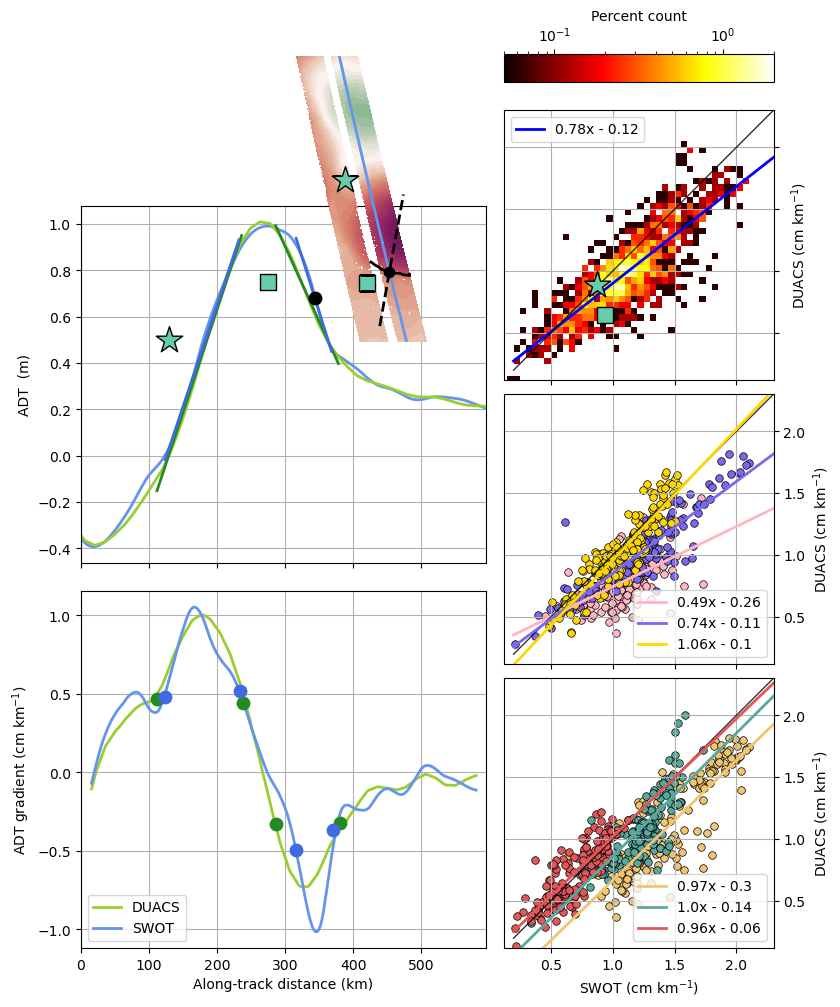

In [311]:
pos_west, pos_east,  pos_south, pos_north  = 10, 20, -43, -32.5  #Reset the area
fig=plt.figure(figsize=(9,14))

### Fronts comparison between SWOT and DUACS - all points

    #Plot
ax0 = fig.add_axes([0.7, 2/3, 0.3, 0.3])
count = distribution(abs(grad_retro_swot), abs(grad_retro_gridded), bins_grad, bins_grad)
im = ax0.pcolormesh(bins_grad, bins_grad, count, norm=colors.LogNorm(.05, 2), cmap='hot', shading='auto')
    #Linear regression
x = abs(grad_retro_swot)
y = abs(grad_retro_gridded)
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax0.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), 'b', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))
    #1:1 line
ax0.plot([0.2, 2.5], [0.2, 2.5], 'k', linewidth=1, alpha=0.8)

    #Set parameter
ax0.tick_params('both', labelsize=ft)
ax0.set_xticklabels([])
ax0.set_ylabel('DUACS (cm km$^{-1}$)', fontsize=ft)
ax0.yaxis.set_label_position("right")
ax0.yaxis.tick_right()
plt.legend(fontsize=ft)
plt.grid()
locs, labels = plt.xticks()
plt.yticks(locs, labels)
ax0.set_aspect('equal')
plt.xlim([0.12,2.3])
plt.ylim([0.12,2.3])

    #Add Colorbar 
pos0 = ax0.get_position()
cax = fig.add_axes([pos0.x0, pos0.y0+pos0.height + 0.02, pos0.width,0.02])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal')
cbar.set_label('Percent count', fontsize=ft)
cbar.ax.tick_params(labelsize=ft)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')



### Fronts comparison between SWOT and DUACS - different quantiles of lenght scale

ax1 = fig.add_axes([pos0.x0, pos0.y0-pos0.height-0.01, pos0.width,pos0.height])

    #Q0 - Q10
    
lcut_up = np.percentile(length_front_swot, 10)
select = np.where(length_front_swot<=lcut_up)[0]

        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax1.scatter(x, y, 30,'lightpink', edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax1.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), 'lightpink', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))
        #1:1 line
ax1.plot([0.2, 2.5], [0.2, 2.5], 'k', linewidth=1, alpha=0.8) 

    #Q25 - Q35
    
lcut = np.percentile(length_front_swot, 25)
lcut_up = np.percentile(length_front_swot, 35)
select = np.where((length_front_swot>=lcut) & (length_front_swot<lcut_up))[0]
        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax1.scatter(x, y, 30, 'mediumslateblue', edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax1.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), 'mediumslateblue', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))

    #Q75 - Q85

lcut = np.percentile(length_front_swot, 75)
lcut_up = np.percentile(length_front_swot, 85)
select = np.where((length_front_swot>=lcut) & (length_front_swot<lcut_up))[0]
        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax1.scatter(x,y,30,'gold',edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax1.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), 'gold', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))

    #Set parameters
ax1.tick_params('both', labelsize=ft)
ax1.set_ylabel('DUACS (cm km$^{-1}$)', fontsize=ft)
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()
plt.grid()
locs, labels = plt.xticks()
plt.yticks(locs, labels)
ax1.set_aspect('equal')
plt.xlim([0.12,2.3])
plt.ylim([0.12,2.3])
ax1.set_xticklabels([])
plt.legend(fontsize=ft, loc='lower right')

### Fronts comparison between SWOT and DUACS - different quantiles of Rossby number

pos1 = ax1.get_position()
ax2 = fig.add_axes([pos1.x0, pos1.y0-pos1.height-0.01, pos1.width,pos0.height])

    #Q90 - Q100

lcut = np.percentile(Rossby_front_swot, 90)
select = np.where(Rossby_front_swot>=lcut)[0]  
        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax2.scatter(x,y,30,'#f0c571', edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax2.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), '#f0c571', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))
        #1:1 line
ax2.plot([0.2, 2.5], [0.2, 2.5], 'k', linewidth=1, alpha=0.8)

    #Q60 - Q70

lcut = np.percentile(Rossby_front_swot, 60)
lcut_up = np.percentile(Rossby_front_swot, 70)
select = np.where((Rossby_front_swot>=lcut) & (Rossby_front_swot<lcut_up))[0]
        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax2.scatter(x,y,30,c='#59a89c', edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax2.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), '#59a89c', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))

    #Q0 - Q10

lcut_up = np.percentile(Rossby_front_swot, 10)
select = np.where(Rossby_front_swot<lcut_up)[0]
        #Plot
x = abs(grad_retro_swot[select])
y = abs(grad_retro_gridded[select])
ax2.scatter(x,y,30,'#e25759', edgecolor='k', linewidth=0.5)
        #Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))
ax2.plot(x_interp,lin_reg.predict(x_interp.reshape(-1, 1)).flatten(), '#e25759', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*100)/100)+ 'x - ' + str(abs(np.round(lin_reg.intercept_[0]*100)/100)))


    #Set parameters
ax2.set_xlabel('SWOT (cm km$^{-1}$)', fontsize=ft)
ax2.set_ylabel('DUACS (cm km$^{-1}$)', fontsize=ft)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.tick_params('both', labelsize=ft)
plt.grid()
locs, labels = plt.xticks()
plt.yticks(locs, labels)
ax2.set_aspect('equal')
plt.xlim([0.12,2.3])
plt.ylim([0.12,2.3])
plt.legend(fontsize=ft, loc='lower right')

### Highlight methodo using one day - one track

id_track = 22
id_date = 9

    #Open files
swot_data = xr.open_dataset(swot_files[id_date])
date64 = np.datetime64(datetime(int(swot_files[id_date][-41:-37]), int(swot_files[id_date][-37:-35]), int(swot_files[id_date][-35:-33])))
ds_sat = ds_ssh.sel(time=date64)
id_select = np.unique(np.where((swot_data.longitude>pos_west) & (swot_data.longitude<pos_east) & (swot_data.latitude>pos_south) & (swot_data.latitude<pos_north))[0])
    
    #Define variables
field_swot = swot_data.ssha_filtered.data[id_select][:,id_track] + swot_data.mdt.data[id_select][:,id_track]
id_nan = np.where(~np.isnan(field_swot)==1)[0]
lon_swot, lat_swot = swot_data.longitude.data[id_select][:,id_track][id_nan], swot_data.latitude.data[id_select][:,id_track][id_nan]
dist_swot = np.hstack([0,np.cumsum(sw.dist(lat_swot,lon_swot,units='km')[0])])
field_swot = field_swot[~np.isnan(field_swot)]
track_vect = np.array([lon_swot[0] - lon_swot[-1], lat_swot[0] - lat_swot[-1]])
track_vect_unit = track_vect/np.linalg.norm(track_vect)
    #Interpolate DUACS on SWOT track
x = xr.DataArray(lon_swot,dims="new_coord")
y = xr.DataArray(lat_swot,dims="new_coord")
field_gridded = (ds_sat.adt).interp(longitude=x, latitude=y).compute().data
    #Smooth SWOT data
dist_swot = moving_average(dist_swot, window)
field_swot = moving_average(field_swot, window)
field_gridded = field_gridded[window//2:-window//2]
    #Cut the data around the Retroflection position
id_up = np.where(dist_all>1200)[0][0]
id_cut = np.where(dist_all>600)[0][0]
field_swot = field_swot[id_cut:id_up]
field_gridded = field_gridded[id_cut:id_up]
dist_swot = dist_swot[id_cut:id_up] - dist_swot[id_cut]

    #Set both axes
        #Axis gradient
pos2 = ax2.get_position()
ax6 = fig.add_axes([pos2.x0-1.5*pos2.width-0.02, pos2.y0, pos2.width*1.5,11*pos2.height/8 - 0.01])
        #Axis ADT
pos3 = ax6.get_position()
ax7 = fig.add_axes([pos3.x0, pos3.y0 + pos3.height+0.02, pos3.width,pos3.height])

    #Plot ADT data
ax7.plot(dist_swot,field_swot, 'cornflowerblue', linewidth=2)
ax7.plot(dist_swot,field_gridded, 'yellowgreen', linewidth=2)

    #Plot gradients
ax6.plot(moving_average(dist_swot, window), moving_average(np.gradient(field_gridded,dist_swot), window)*100, 'yellowgreen', linewidth=2)
ax6.plot(moving_average(dist_swot, window), moving_average(np.gradient(field_swot,dist_swot), window)*100, 'cornflowerblue', linewidth=2)

    #Add an inset with a SWOT pass

proj = ccrs.Mercator(central_longitude=17.125,min_latitude=-45,max_latitude=-30.5)
crs = ccrs.PlateCarree()
pos_west,pos_east,pos_south,pos_north  = 15,19.25,-42,-37  #Reset the area
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent

    #Set axe
pos6 = ax7.get_position()
ax4 = fig.add_axes([pos6.x0+ pos6.width*1/3-0.02, pos6.y0 + pos6.height/2+0.03, pos6.width*0.8, pos6.height*0.8],projection=proj, zorder=2)
ax4.set_extent(extent)
ax4.set_frame_on(False)
    #Plot SWOT ADT
ax4.pcolormesh(swot_data.longitude.data[id_select], swot_data.latitude.data[id_select], swot_data.ssha_filtered.data[id_select]+swot_data.mdt.data[id_select],cmap=cmap, norm=norm,transform=crs, zorder=10)
ax4.plot(swot_data.longitude[id_select][:,id_track],swot_data.latitude[id_select][:,id_track], 'cornflowerblue',linewidth=2,transform=crs, zorder=32);

    
    #Plot fronts identification
    

        #Plot detection North - Gridded
dist = dist_swot[:np.argmax(field_gridded)+1]
field = field_gridded[:np.argmax(field_gridded)+1]
            #Plot regression
lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'north')
ax7.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'forestgreen', linewidth=2,label= str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$\n' + str(int(ll)) + ' km')
            #Find the front's extension
grad = np.gradient(field,dist)
grad_smooth = moving_average(grad, window)
id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]
lim_grad = thres*grad_smooth[id_max_extrema]
if len(np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0])>0:
    id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0][0]+window//2
else:
    id1 = window//2
if len(np.where(grad_smooth[id_max_extrema:]<lim_grad)[0])>0:
    id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]<lim_grad)[0][0]+window//2+1
else:
    id2=-window//2
            #Plot
ax6.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 80, 'forestgreen', zorder=10)
#id_save_gridded = mmax_grad+window//2
#ll = np.round(absc[-1] - absc[0])
x_duacs_north = lin_reg.coef_[0]*100


        #Plot detection North - SWOT
dist = dist_swot[:np.argmax(field_swot)+1]
field = field_swot[:np.argmax(field_swot)+1]
            #Plot regression
lin_reg, absc = compute_grad_SWOT(dist, field, 'north', loc_front)
ax7.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'royalblue', linewidth=2, label= str(np.round(lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$\n' + str(int(ll)) + ' km')
            #Find the front's extension
grad = np.gradient(field,dist)
grad_smooth = moving_average(grad, window)
id_list_extrema = np.array(argrelextrema(grad_smooth, np.greater))[0]
id_max_extrema = id_list_extrema[np.argmax(grad_smooth[id_list_extrema])]
if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
    id_extre_sort = np.array(argrelextrema(grad_smooth, np.greater))[0][np.flip(np.argsort(grad_smooth[argrelextrema(grad_smooth, np.greater)]))[1:]]
    pot = id_extre_sort[0]
    while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
        id_extre_sort = id_extre_sort[1:]
        pot = id_extre_sort[0]
    if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
        id_max_extrema = pot
    else:
        id_max_extrema = np.argmax(grad_smooth)
lim_grad = thres*grad_smooth[id_max_extrema]
if len(np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0])>0:
    id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])<lim_grad)[0][0]+window//2
else:
    id1 = window//2
if len(np.where(grad_smooth[id_max_extrema:]<lim_grad)[0])>0:
    id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]<lim_grad)[0][0]+window//2+1
else:
    id2=-window//2
            #Plot
ax6.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 80, 'royalblue', zorder=10)
#id_save_swot = mmax_grad+window//2
#ll = np.round(absc[-1] - absc[0])
#lambda_north = ll
x_swot_north = lin_reg.coef_[0]*100
            #Add a symbol to recognize this northern front in panel a and c
ax7.scatter(130, 0.5, 400,'mediumaquamarine', '*', edgecolor='k', zorder=20)
ax0.scatter(x_swot_north, x_duacs_north, 400,'mediumaquamarine', '*', edgecolor='k', zorder=20)


        #Plot detection South - Gridded
dist = dist_swot[np.argmax(field_gridded):]
field = field_gridded[np.argmax(field_gridded):]
            #Plot regression
lin_reg, absc, loc_front = compute_grad_DUACS(dist, field, 'south')
ax7.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'forestgreen', linewidth=2,label= str(np.round(-lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$\n' + str(int(ll)) + ' km')
            #Find the front's extension
grad = np.gradient(field,dist)
grad_smooth = moving_average(grad, window)
id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]
lim_grad = thres*grad_smooth[id_max_extrema]

if len(np.where(grad_smooth[id_max_extrema:]>lim_grad)[0])>0:
    id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]>lim_grad)[0][0]+window//2+1
else:
    id2 = -window//2
if len(np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0])>0:
    id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0][0]+window//2
else:
    id1=window//2
            #Plot
ax6.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 80, 'forestgreen', zorder=10)
x_duacs_south = lin_reg.coef_[0]*100
#ll = np.round(absc[-1] - absc[0])

        #Plot detection South - SWOT
dist = dist_swot[np.argmax(field_swot):]
field = field_swot[np.argmax(field_swot):]
            #Plot regression
lin_reg, absc = compute_grad_SWOT(dist, field, 'south', loc_front)
ax7.plot(absc,lin_reg.predict(absc.reshape(-1, 1)).flatten(), 'royalblue', linewidth=2, label= str(np.round(-lin_reg.coef_[0][0]*10000)/100) + ' cm km$^{-1}$\n' + str(int(ll)) + ' km')
            #Find the front's extension
grad = np.gradient(field,dist)
grad_smooth = moving_average(grad, window)
id_list_extrema = np.array(argrelextrema(grad_smooth, np.less))[0]
id_max_extrema = id_list_extrema[np.argmin(grad_smooth[id_list_extrema])]
if abs(moving_average(dist, window)[id_max_extrema]-loc_front)>dist_front:
    id_extre_sort = np.array(argrelextrema(grad_smooth, np.less))[0][np.argsort(grad_smooth[argrelextrema(grad_smooth, np.less)])[1:]]
    pot = id_extre_sort[0]
    while (abs(moving_average(dist, window)[pot]-loc_front)>dist_front) & (len(id_extre_sort)>1):
        id_extre_sort = id_extre_sort[1:]
        pot = id_extre_sort[0]
    if abs(moving_average(dist, window)[pot]-loc_front)<dist_front:
        id_max_extrema = pot
    else:
        id_max_extrema = np.argmin(grad_smooth)
lim_grad = thres*grad_smooth[id_max_extrema]
if len(np.where(grad_smooth[id_max_extrema:]>lim_grad)[0])>0:
    id2 = id_max_extrema + np.where(grad_smooth[id_max_extrema:]>lim_grad)[0][0]+window//2+1
else:
    id2 = -window//2
if len(np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0])>0:
    id1 = id_max_extrema - np.where(np.flip(grad_smooth[:id_max_extrema])>lim_grad)[0][0]+window//2
else:
    id1=window//2
            #Plot
ax6.scatter(dist[[id1,id2]],grad[[id1,id2]]*100, 80, 'royalblue', zorder=10)
x_swot_south = lin_reg.coef_[0]*100
#ll = np.round(absc[-1] - absc[0])
#lambda_south = ll
            #Add front location
lon_c, lat_c = moving_average(lon_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2], moving_average(lat_swot, window)[id_cut:id_up][np.argmax(field_swot):][id_max_extrema+window//2]
adt_c = field[id_max_extrema+window//2]
ax7.scatter(dist[id_max_extrema+window//2],adt_c, 80, 'k', zorder=10)
            #Add corresponding contour on SWOT inset
id_sel = np.unique(np.where((swot_data.longitude>lon_c-delta) & (swot_data.longitude<lon_c+delta) & (swot_data.latitude>lat_c-delta) & (swot_data.latitude<lat_c+delta))[0])
ds_sel_adt = swot_data.ssha_filtered.data[id_sel] + swot_data.mdt.data[id_sel]
row, col = np.where(~np.isnan(ds_sel_adt)==1)
cs = ax4.tricontour(swot_data.longitude.data[id_sel][row,col].flatten(), tem.latitude.data[id_sel][row,col].flatten(), ds_sel_adt[row,col].flatten(), [adt_c],transform=crs, colors='k', linewidths=2, zorder=12)
            #Add a symbol to recognize this northern front in panel a and c
ax7.scatter(275, 0.75, 120,'mediumaquamarine', 's', edgecolor='k',zorder=20)
ax0.scatter(abs(x_swot_south), abs(x_duacs_south), 120,'mediumaquamarine', 's', edgecolor='k',zorder=20)
            

        #Set parameters 
ax7.set_ylabel('ADT  (m)', fontsize=ft)
ax7.set_xticklabels([])
ax7.set_xlim([np.min(dist_swot),np.max(dist_swot)])
ax6.set_xlim([np.min(dist_swot),np.max(dist_swot)])
ax6.grid(True)
ax7.grid(True)
ax6.tick_params('both', labelsize=ft)
ax7.tick_params('both', labelsize=ft)
ax6.set_xlabel('Along-track distance (km)', fontsize=ft)
ax6.set_ylabel('ADT gradient (cm km$^{-1}$)', fontsize=ft)
lines = ax6.get_lines()
legend1 = ax6.legend([lines[i] for i in [0,1]], ['DUACS', 'SWOT'], loc='lower left', fontsize=ft)

### Add details to the inset
list_inters = []
idx_ct = []
for j in range(len(cs.allsegs[0])):
    lines = LineString(cs.allsegs[0][j]).intersection(LineString(np.vstack((lon_swot,lat_swot)).T))
    if not(lines.is_empty):
        if lines.geom_type == 'MultiPoint':
            lines = lines.geoms[0]
        list_inters.append(sw.dist([lat_c, lines.y],[lon_c, lines.x],units='km')[0])
        idx_ct.append(j)
    
contour_select = idx_ct[np.argmin(list_inters)]
    
xsel=[]
ysel=[]
for p in range(len(cs.allsegs[0][contour_select][:,0])):
    if sw.dist([lat_c, cs.allsegs[0][contour_select][p,1]],[lon_c, cs.allsegs[0][contour_select][p,0]],units='km')[0]<rr:
        xsel.append(cs.allsegs[0][contour_select][p,0])
        ysel.append(cs.allsegs[0][contour_select][p,1])
xsel=np.array(xsel)
ysel=np.array(ysel)

lin_reg = LinearRegression()
lin_reg.fit(xsel.reshape(-1, 1), ysel.reshape(-1, 1))

y_pred = lin_reg.predict(np.array([xsel[0], xsel[-1]]).reshape(-1, 1))[:,0]
reg_vect = np.array([xsel[0] - xsel[-1], y_pred[0] - y_pred[-1]])
reg_vect_unit = reg_vect/np.linalg.norm(reg_vect)

angle = np.rad2deg(np.arccos(np.dot(track_vect_unit,reg_vect_unit)))
if angle >90:
    angle = 180 - angle

for coll in cs.collections:
    coll.remove()

xsel=[]
ysel=[]
for p in range(len(cs.allsegs[0][contour_select][:,0])):
    if sw.dist([lat_c, cs.allsegs[0][contour_select][p,1]],[lon_c, cs.allsegs[0][contour_select][p,0]],units='km')[0]<40:
        xsel.append(cs.allsegs[0][contour_select][p,0])
        ysel.append(cs.allsegs[0][contour_select][p,1])
xsel=np.array(xsel)
ysel=np.array(ysel)
#Add the contour used for the linear regression
ax4.plot(xsel, ysel, 'k', transform=crs, linewidth=2, zorder=40)

#Plot perpendicular vector
    #Find intersection point
line1 = LineString(np.vstack((xsel,ysel)).T)
line2 = LineString(np.vstack((lon_swot,lat_swot)).T)
interp_point = np.array([line1.intersection(line2).x,line1.intersection(line2).y])
c = - np.sum(reg_vect_unit*interp_point)
y_perp = - (reg_vect_unit[0]*xsel[15:-20] + c)/reg_vect_unit[-1]
    #Plot
ax4.plot(xsel[15:-20], y_perp, 'k', linestyle='--', transform=crs, linewidth=2, zorder=40)
ax4.scatter(interp_point[0], interp_point[-1], 40, 'k', transform=crs, linewidth=2, zorder=40)
    #Add symbol to recognize the fronts diplayed in panel a and b
ax4.scatter(16.8,-39.2,400,'mediumaquamarine', '*', edgecolor='k',transform=crs,zorder=50)
ax4.scatter(17.3,-41,120,'mediumaquamarine', 's', edgecolor='k',transform=crs,zorder=50)

#fig.savefig(path_save +'Figure_3_submission.png',bbox_inches='tight',dpi=300)

# Plot Figure S2

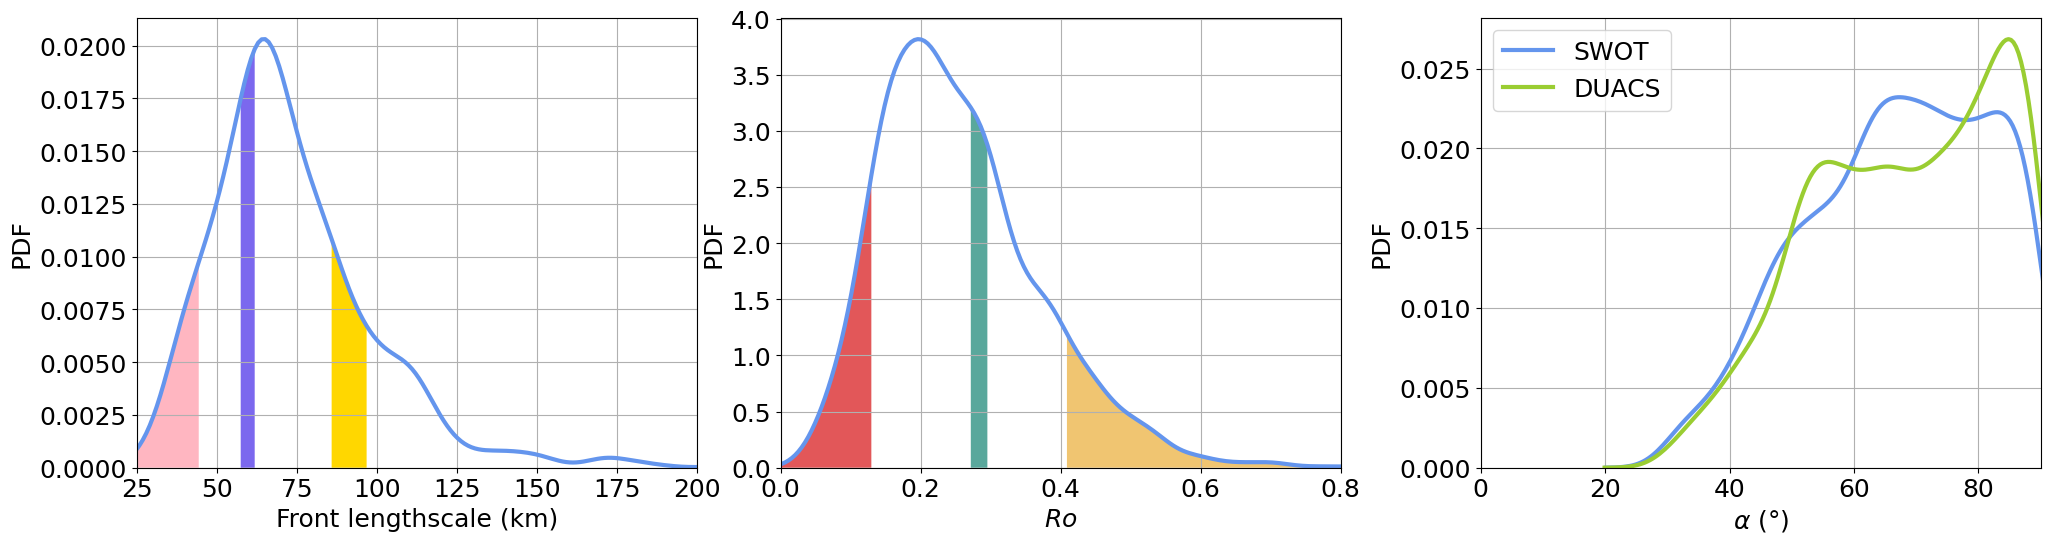

In [316]:
ft=18
fig=plt.figure(figsize=(14,9))
ax2 = fig.add_axes([0.1, 0.1, 0.4,0.5])

# PDF length scales
    #Plot 
kde = sns.kdeplot(length_front_swot, color='cornflowerblue', linewidth=3)
    #Highlight the different quantiles used in Figure 3
line = kde.lines[0]
x, y = line.get_data()
        #Q0-Q10
lcut = np.percentile(length_front_swot, 10)
id1 = np.where(x>lcut)[0][0]
xarray = np.concatenate((x[:id1],np.flip(x[:id1]),[x[0]]))
yarray = np.concatenate((np.zeros_like(y[:id1]),np.flip(y[:id1]),[0]))
ax2.fill(xarray,yarray, 'lightpink')
        #Q25-Q35
lcut = np.percentile(length_front_swot, 25)
lcut_up = np.percentile(length_front_swot, 35)
id1 = np.where(x>lcut)[0][0]
id2 = np.where(x>lcut_up)[0][0]
xarray = np.concatenate((x[id1:id2],np.flip(x[id1:id2]),[x[id1]]))
yarray = np.concatenate((np.zeros_like(y[id1:id2]),np.flip(y[id1:id2]),[0]))
ax2.fill(xarray,yarray, 'mediumslateblue')
        #Q75-85
lcut = np.percentile(length_front_swot, 75)
lcut_up = np.percentile(length_front_swot, 85)
id1 = np.where(x>lcut)[0][0]
id2 = np.where(x>lcut_up)[0][0]
xarray = np.concatenate((x[id1:id2],np.flip(x[id1:id2]),[x[id1]]))
yarray = np.concatenate((np.zeros_like(y[id1:id2]),np.flip(y[id1:id2]),[0]))
ax2.fill(xarray,yarray, 'gold')
    #Parameters
ax2.set_xlim([25,200])
ax2.set_xlabel('Front lengthscale (km)', fontsize=ft)
ax2.set_ylabel('PDF', fontsize=ft)
ax2.tick_params('both', labelsize=ft)
plt.grid()

# PDF Ro
ax3 = fig.add_axes([0.56, 0.1, 0.4,0.5])
    #Plot 
kde = sns.kdeplot(Rossby_front_swot, color='cornflowerblue', linewidth=3)
    #Highlight the different quantiles used in Figure 3
line = kde.lines[0]
x, y = line.get_data()
        #Q90-Q100
lcut = np.percentile(Rossby_front_swot, 90)
id1 = np.where(x>lcut)[0][0]
xarray = np.concatenate((x[id1:],np.flip(x[id1:]),[x[id1]]))
yarray = np.concatenate((np.zeros_like(y[id1:]),np.flip(y[id1:]),[0]))
ax3.fill(xarray,yarray, '#f0c571')
        #Q60-Q70
lcut = np.percentile(Rossby_front_swot, 60)
lcut_up = np.percentile(Rossby_front_swot, 70)
id1 = np.where(x>lcut)[0][0]
id2 = np.where(x>lcut_up)[0][0]
xarray = np.concatenate((x[id1:id2],np.flip(x[id1:id2]),[x[id1]]))
yarray = np.concatenate((np.zeros_like(y[id1:id2]),np.flip(y[id1:id2]),[0]))
ax3.fill(xarray,yarray, '#59a89c')
        #Q0-Q10
lcut = np.percentile(Rossby_front_swot, 10)
id1 = np.where(x>lcut)[0][0]
xarray = np.concatenate((x[:id1],np.flip(x[:id1]),[x[0]]))
yarray = np.concatenate((np.zeros_like(y[:id1]),np.flip(y[:id1]),[0]))
ax3.fill(xarray,yarray, '#e25759')
    #Parameters
ax3.set_xlim([0,0.8])
ax3.set_xlabel('$Ro$', fontsize=ft)
ax3.set_ylabel('PDF', fontsize=ft)
ax3.tick_params('both', labelsize=ft)
plt.grid()

# PDF angle of attack
ax4 = fig.add_axes([0.56*2-0.06, 0.1, 0.4,0.5])
    #Plot 
kde = sns.kdeplot(angle_swot, color='cornflowerblue', linewidth=3)
kde = sns.kdeplot(angle_gridded, color='yellowgreen', linewidth=3)
lines = ax4.get_lines()
legend1 = ax4.legend([lines[i] for i in [0,1]], ['SWOT', 'DUACS'], loc='upper left', fontsize=ft)

ax4.set_xlim([0,90])
ax4.set_xlabel(r'$\alpha$ (°)', fontsize=ft)
ax4.set_ylabel('PDF', fontsize=ft)
ax4.tick_params('both', labelsize=ft)
plt.grid()

#fig.savefig(path_save + 'Figure_S2_submission.png',bbox_inches='tight',dpi=300)